# Mutaties Etten-Leur: 2022 → 2025

Wat is er gebouwd, gesloopt en zichtbaar veranderd in het pilotgebied, op basis van
twee luchtfoto-jaargangen (`2022_orthoHR` en `2025_orthoHR`) en de BAG?

- **Nieuwbouw** komt uit de BAG (bouwjaar ≥ 2022) — gegarandeerde veranderingen.
- **Visuele veranderingen** (zonnepanelen, dakrenovaties) komen uit een verschilscore
  per pand tussen de twee foto's — geen model nodig, wel een rangorde.

Elke verandering wordt getoond als **voor/na-paar met een gele markeringsbox** —
geen rood/cyaan-composieten, gewoon twee foto's naast elkaar.

Vereist: `python scripts/02_download_tiles.py --laag 2022_orthoHR` en idem `2025_orthoHR`,
plus `data/bag/panden_alle.geojson` (maakt dit notebook zelf als hij ontbreekt).

In [1]:
import io, json, sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from shapely.geometry import shape

REPO = Path.cwd().resolve()
if REPO.name == 'notebooks':
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'scripts'))
from common import laad_config
from pdok import fetch_bag_panden, make_session, wms_get_map

cfg = laad_config(REPO / 'config.yaml')
DATA = REPO / cfg['paden']['data']
RES = cfg['luchtfoto']['resolutie']
PX = cfg['luchtfoto']['tegelgrootte']
STAP = PX * RES
XMIN, YMIN = cfg['gebied']['bbox'][0], cfg['gebied']['bbox'][1]
OUD_LAAG, NIEUW_LAAG = '2022_orthoHR', '2025_orthoHR'
OUD_MAP, NIEUW_MAP = DATA / f'tiles_{OUD_LAAG}', DATA / f'tiles_{NIEUW_LAAG}'
sessie = make_session()

for m in (OUD_MAP, NIEUW_MAP):
    assert (m / 'tiles.json').exists(), f'{m} ontbreekt — draai stap 02 met --laag'
idx_oud = json.loads((OUD_MAP / 'tiles.json').read_text())
idx_nieuw = json.loads((NIEUW_MAP / 'tiles.json').read_text())

bag_pad = DATA / 'bag' / 'panden_alle.geojson'
if not bag_pad.exists():
    features = fetch_bag_panden(sessie, cfg['bag']['wfs_url'], tuple(cfg['gebied']['bbox']),
                                alleen_in_gebruik=False)
    bag_pad.write_text(json.dumps({'type': 'FeatureCollection', 'features': features}))
panden = json.loads(bag_pad.read_text())['features']
print(f'{len(panden)} BAG-panden, {len(set(idx_oud) & set(idx_nieuw))} tegelparen geladen')

2849 BAG-panden, 455 tegelparen geladen


## 1. Wat zegt de BAG over deze periode?

In [2]:
nieuwbouw = sorted((f for f in panden if (f['properties'].get('bouwjaar') or 0) >= 2022),
                   key=lambda f: f['properties']['bouwjaar'])
sloop = [f for f in panden if 'loop' in (f['properties'].get('status') or '')]
verbouwing = [f for f in panden if f['properties'].get('status') == 'Verbouwing pand']

print('Nieuwbouw per bouwjaar:')
for jaar, n in sorted(Counter(f['properties']['bouwjaar'] for f in nieuwbouw).items()):
    print(f'  {jaar}: {n} panden' + ('  (in aanbouw op de 2025-foto)' if jaar >= 2026 else ''))
print(f'Sloopvergunning verleend: {len(sloop)} panden')
print(f'Verbouwing pand:          {len(verbouwing)} panden')

Nieuwbouw per bouwjaar:
  2022: 18 panden
  2023: 15 panden
  2024: 21 panden
  2025: 15 panden
  2026: 26 panden  (in aanbouw op de 2025-foto)
Sloopvergunning verleend: 5 panden
Verbouwing pand:          4 panden


## 2. Voor/na-weergave

Helper: zoek (of haal) het beeldpaar rond een pand, teken een gele box om de
pandcontour op beide jaren, en toon ze naast elkaar.

In [3]:
MARKEER = '#FFD400'

def tegel_id_voor(x, y):
    return f't_{int((x - XMIN) // STAP):04d}_{int((y - YMIN) // STAP):04d}'

def beeldpaar_rond(geom):
    """(oud, nieuw, geo-bbox) rond het pand; grid-tegels of anders directe WMS-crop."""
    cx, cy = geom.centroid.x, geom.centroid.y
    tid = tegel_id_voor(cx, cy)
    if tid in idx_oud and tid in idx_nieuw:
        return (Image.open(OUD_MAP / idx_oud[tid]['image']).convert('RGB'),
                Image.open(NIEUW_MAP / idx_nieuw[tid]['image']).convert('RGB'),
                idx_oud[tid]['bbox'])
    halve = STAP / 2
    bbox = (cx - halve, cy - halve, cx + halve, cy + halve)
    beelden = [Image.open(io.BytesIO(wms_get_map(sessie, cfg['luchtfoto']['wms_url'],
                                                 laag, bbox, PX, PX))).convert('RGB')
               for laag in (OUD_LAAG, NIEUW_LAAG)]
    return beelden[0], beelden[1], list(bbox)

def markeer_en_crop(beeld, geom, bbox, marge_m=14):
    gx0, gy0, gx1, gy1 = geom.bounds
    x0, x1 = (gx0 - bbox[0]) / RES, (gx1 - bbox[0]) / RES
    y0, y1 = (bbox[3] - gy1) / RES, (bbox[3] - gy0) / RES
    kopie = beeld.copy()
    ImageDraw.Draw(kopie).rectangle([x0, y0, x1, y1], outline=MARKEER, width=4)
    m = marge_m / RES
    crop = (max(0, x0 - m), max(0, y0 - m), min(PX, x1 + m), min(PX, y1 + m))
    return kopie.crop(crop)

def toon_voor_na(rijen, titel, bewaar=None):
    if not rijen:
        print('(geen voorbeelden)'); return
    fig, assen = plt.subplots(len(rijen), 2, figsize=(9, 4.4 * len(rijen)), squeeze=False)
    for (geom, onderschrift), (as_o, as_n) in zip(rijen, assen):
        oud, nieuw, bbox = beeldpaar_rond(geom)
        as_o.imshow(markeer_en_crop(oud, geom, bbox))
        as_n.imshow(markeer_en_crop(nieuw, geom, bbox))
        as_o.set_title(f'2022 — {onderschrift}', fontsize=9, loc='left')
        as_n.set_title('2025', fontsize=9, loc='left')
        as_o.axis('off'); as_n.axis('off')
    fig.suptitle(titel, fontsize=12)
    plt.tight_layout()
    if bewaar:
        fig.savefig(bewaar, dpi=110, bbox_inches='tight')
    plt.show()

print('Helpers klaar.')

Helpers klaar.


## 3. Nieuwbouw — verschenen tussen de twee foto's

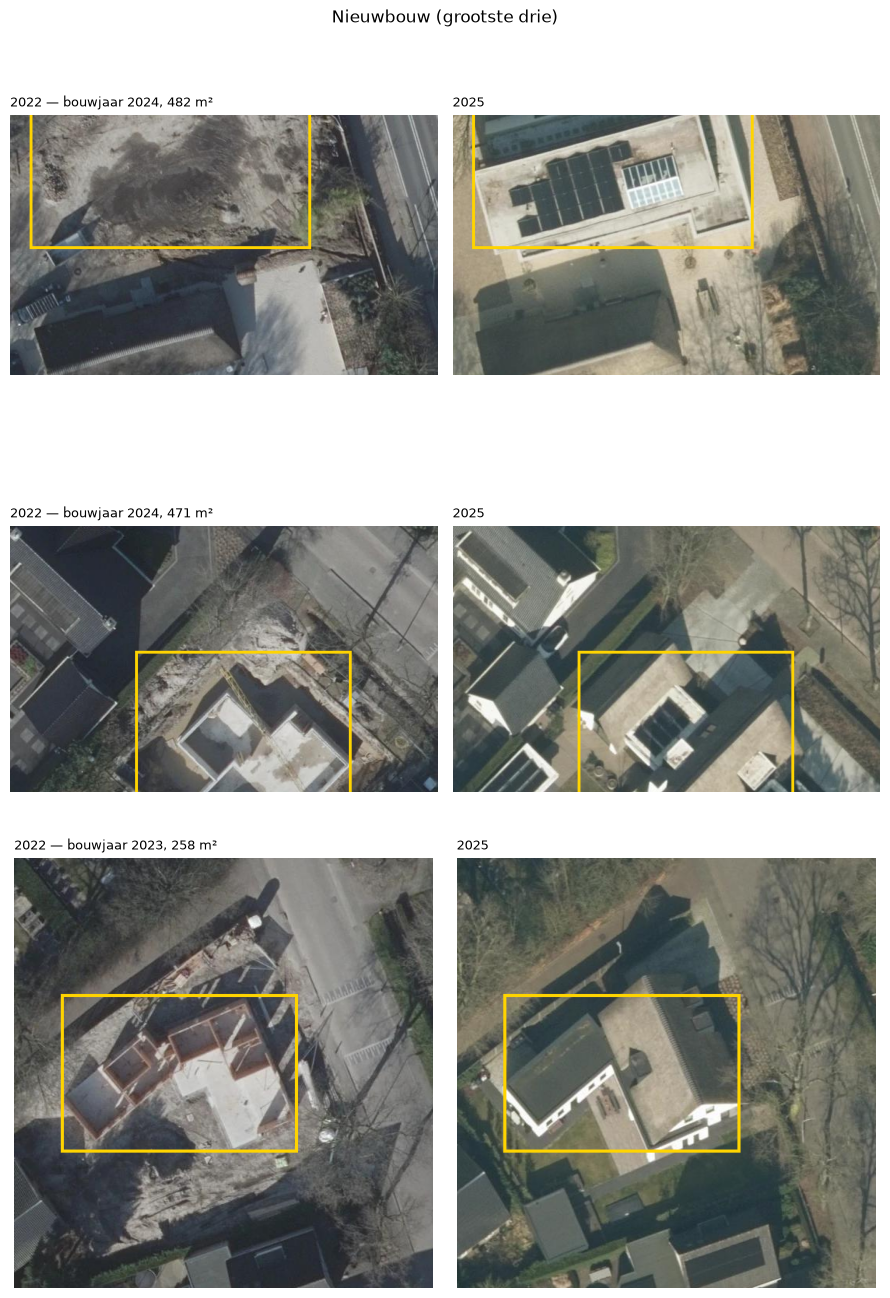

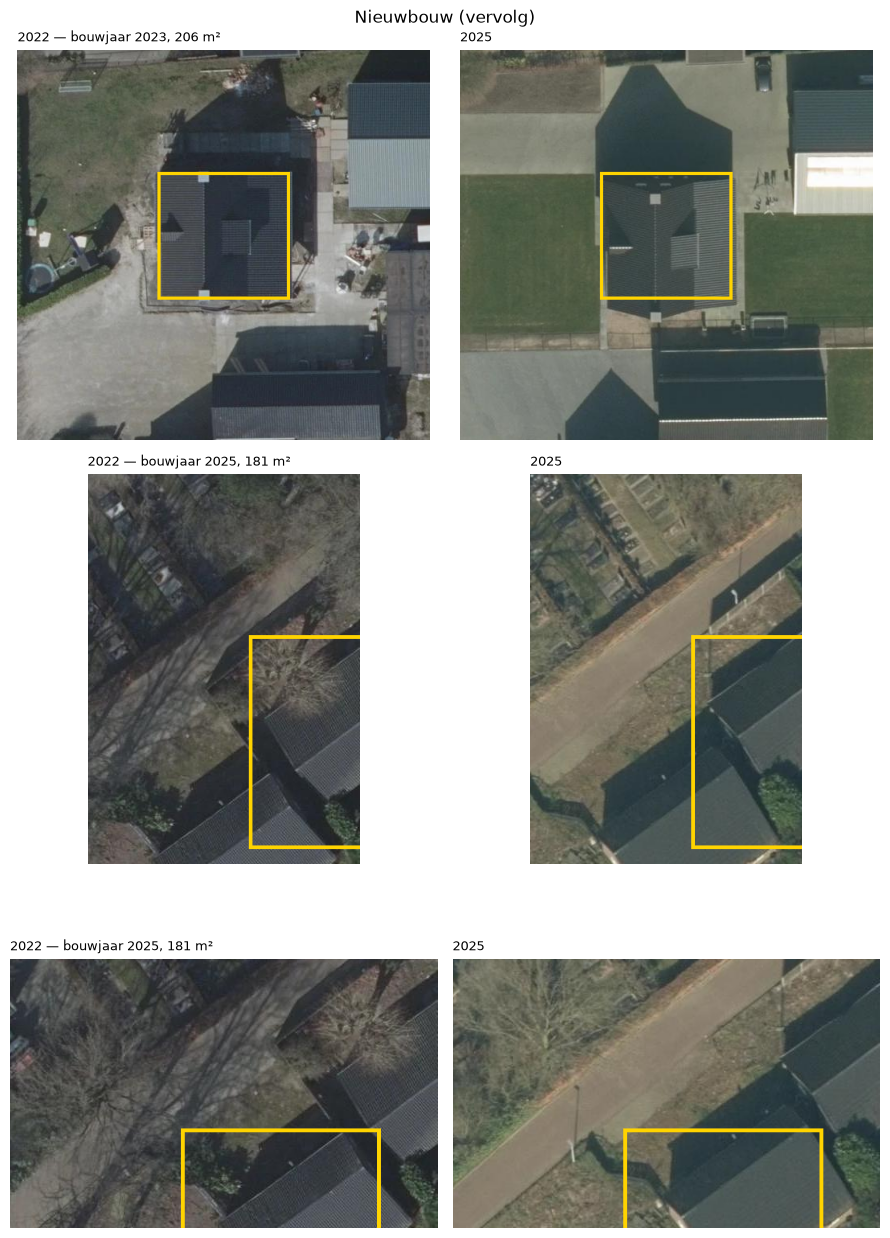

In [4]:
voorbeelden = [f for f in nieuwbouw if 2023 <= f['properties']['bouwjaar'] <= 2025]
voorbeelden = sorted(voorbeelden, key=lambda f: -(f['properties'].get('oppervlakte_max') or 0))[:6]
rijen = [(shape(f['geometry']),
          f"bouwjaar {f['properties']['bouwjaar']}, "
          f"{f['properties'].get('oppervlakte_max') or '?'} m²")
         for f in voorbeelden]
bewaar_map = DATA / 'mutaties_preview'
bewaar_map.mkdir(exist_ok=True)
toon_voor_na(rijen[:3], 'Nieuwbouw (grootste drie)', bewaar=bewaar_map / 'nieuwbouw.jpg')
toon_voor_na(rijen[3:], 'Nieuwbouw (vervolg)')

## 4. In aanbouw op de 2025-foto (bouwjaar 2026 / bouw gestart)

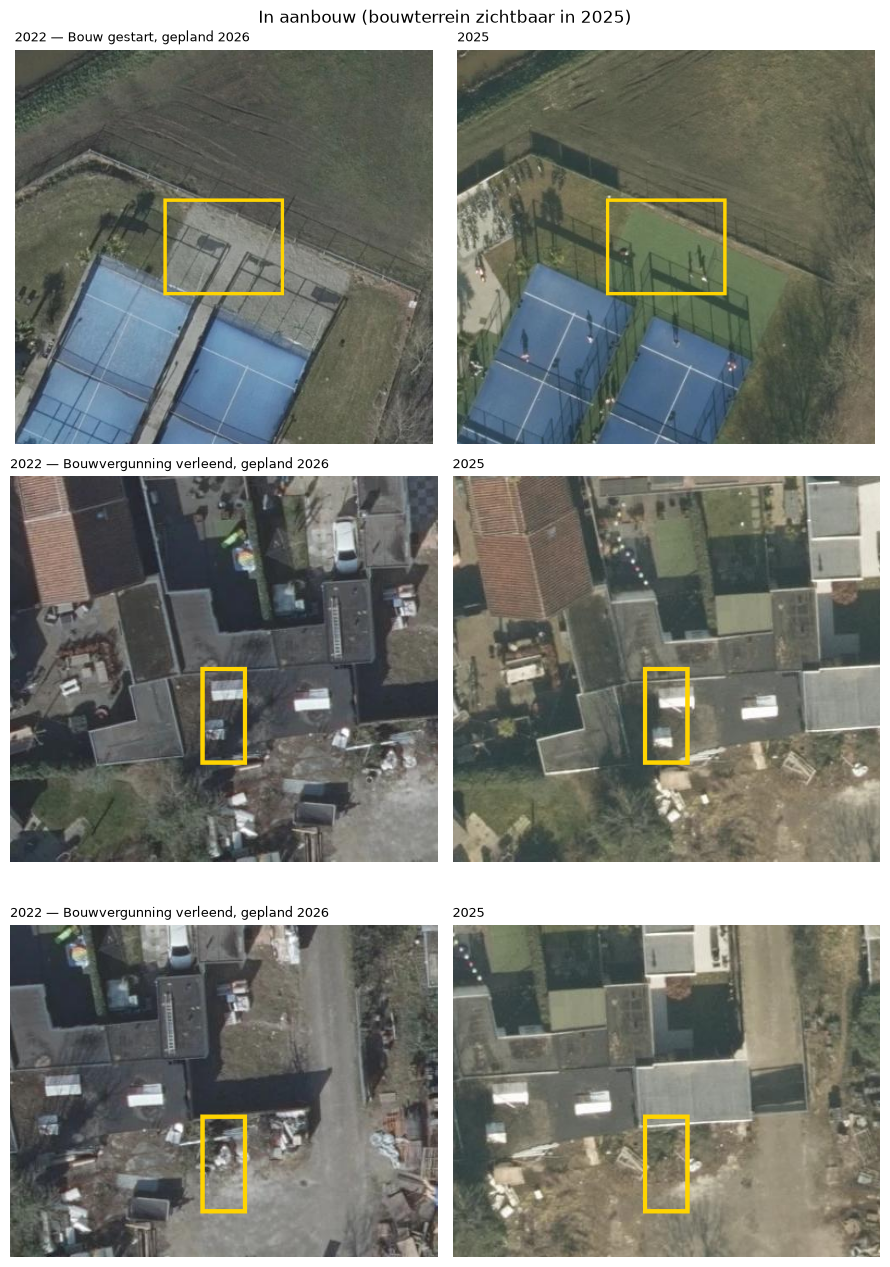

Totaal in aanbouw: 26 panden


In [5]:
in_aanbouw = [f for f in panden
              if (f['properties'].get('bouwjaar') or 0) >= 2026
              or f['properties'].get('status') == 'Bouw gestart']
rijen = [(shape(f['geometry']),
          f"{f['properties'].get('status')}, gepland {f['properties'].get('bouwjaar')}")
         for f in in_aanbouw[:3]]
toon_voor_na(rijen, 'In aanbouw (bouwterrein zichtbaar in 2025)')
print(f'Totaal in aanbouw: {len(in_aanbouw)} panden')

## 5. Sloop en verbouwing

Let op: "Sloopvergunning verleend" betekent dat sloop *mag* — op de foto zie je of het
al gebeurd is. Echt gesloopte panden verdwijnen uit de BAG-levering en zijn alleen
via de visuele verschilscore (sectie 6) terug te vinden.

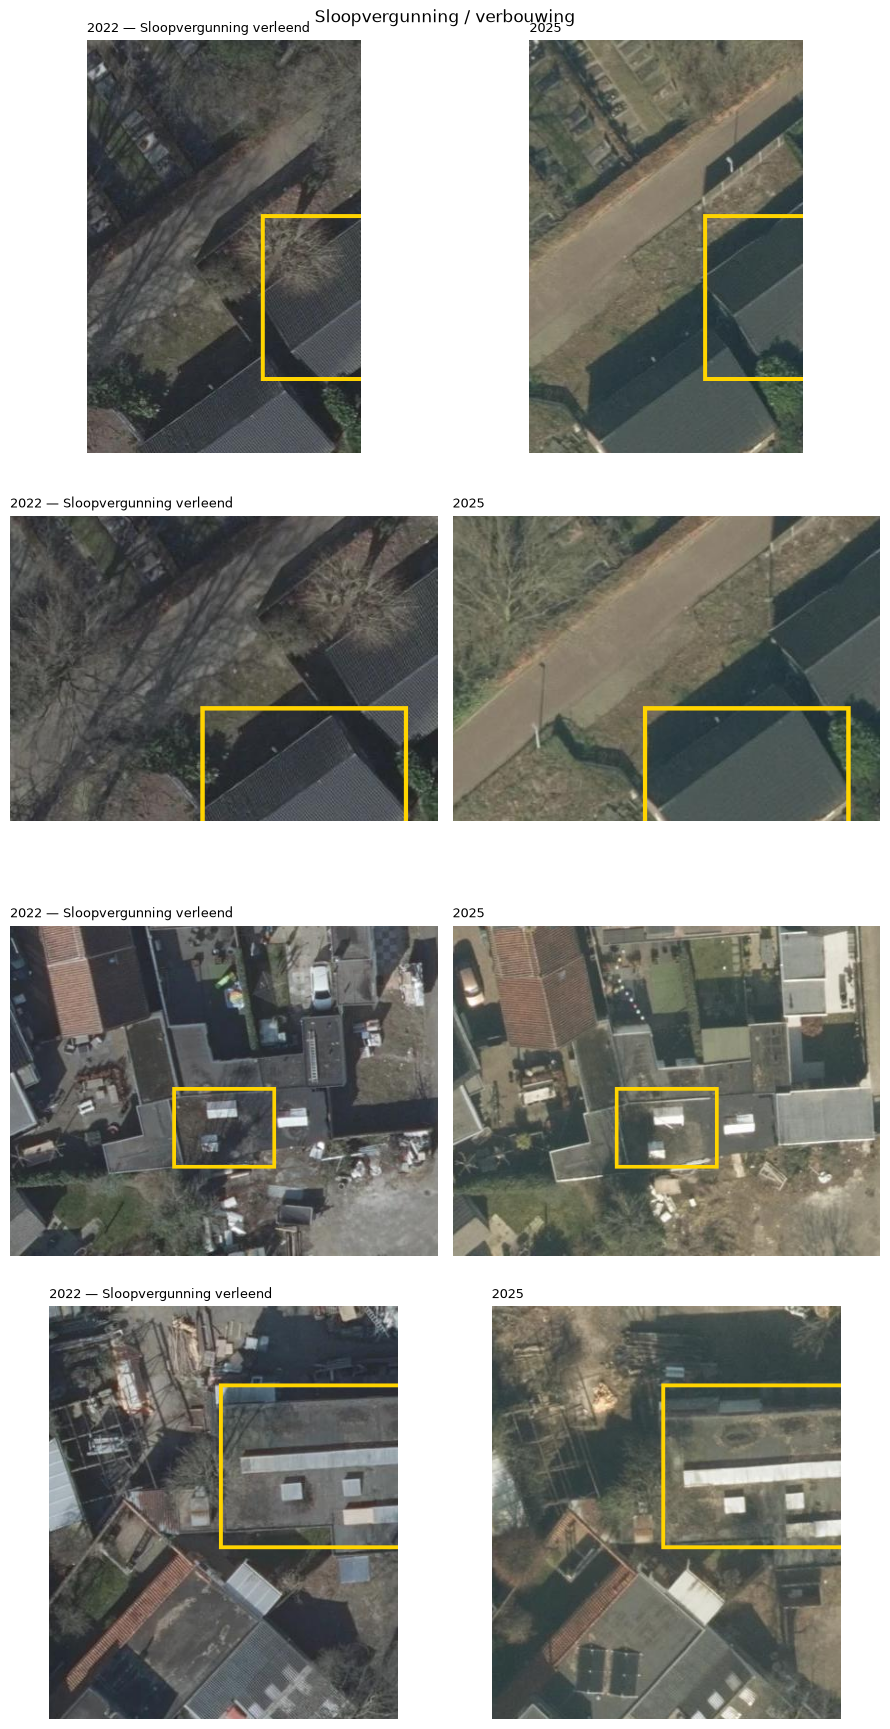

In [6]:
rijen = [(shape(f['geometry']), f['properties'].get('status'))
         for f in (sloop + verbouwing)[:4]]
toon_voor_na(rijen, 'Sloopvergunning / verbouwing', bewaar=bewaar_map / 'sloop_verbouwing.jpg')

## 6. Grootste visuele veranderingen (zonder model)

Per pand: beide foto's per tegel genormaliseerd (z-score, dempt lichtverschil) en het
gemiddelde absolute verschil binnen de pandcontour berekend. De toppers zijn vrijwel
altijd echte mutaties: zonnepanelen geplaatst, dak gerenoveerd, opgeleverd of gesloopt.

1738 panden gescoord; top 8 (excl. bekende nieuwbouw) hieronder.


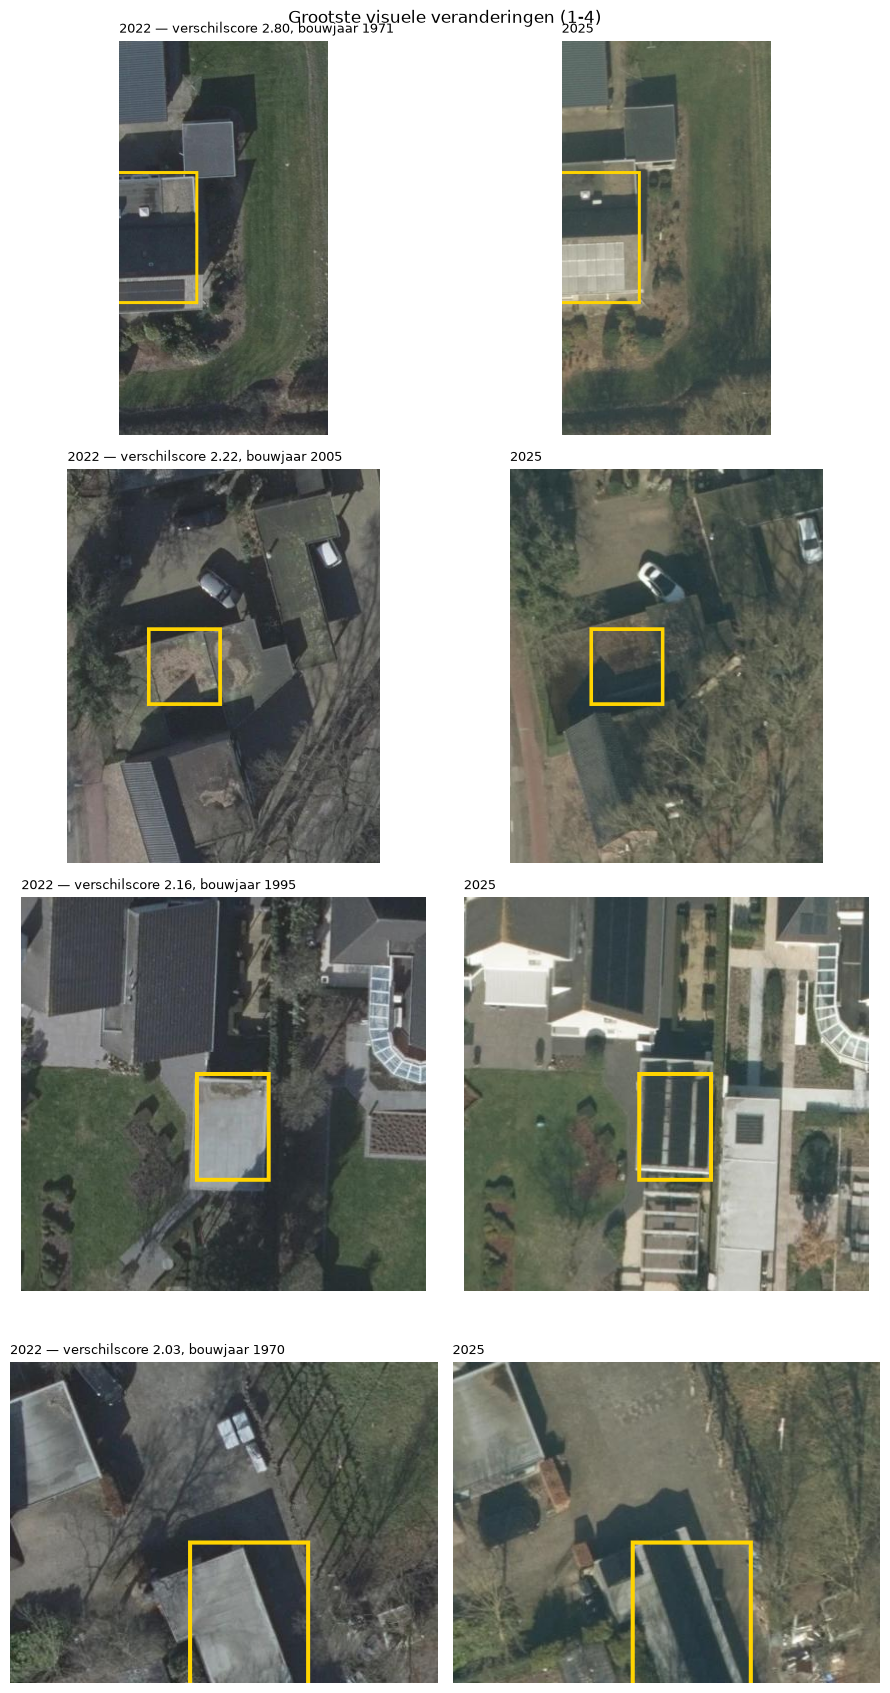

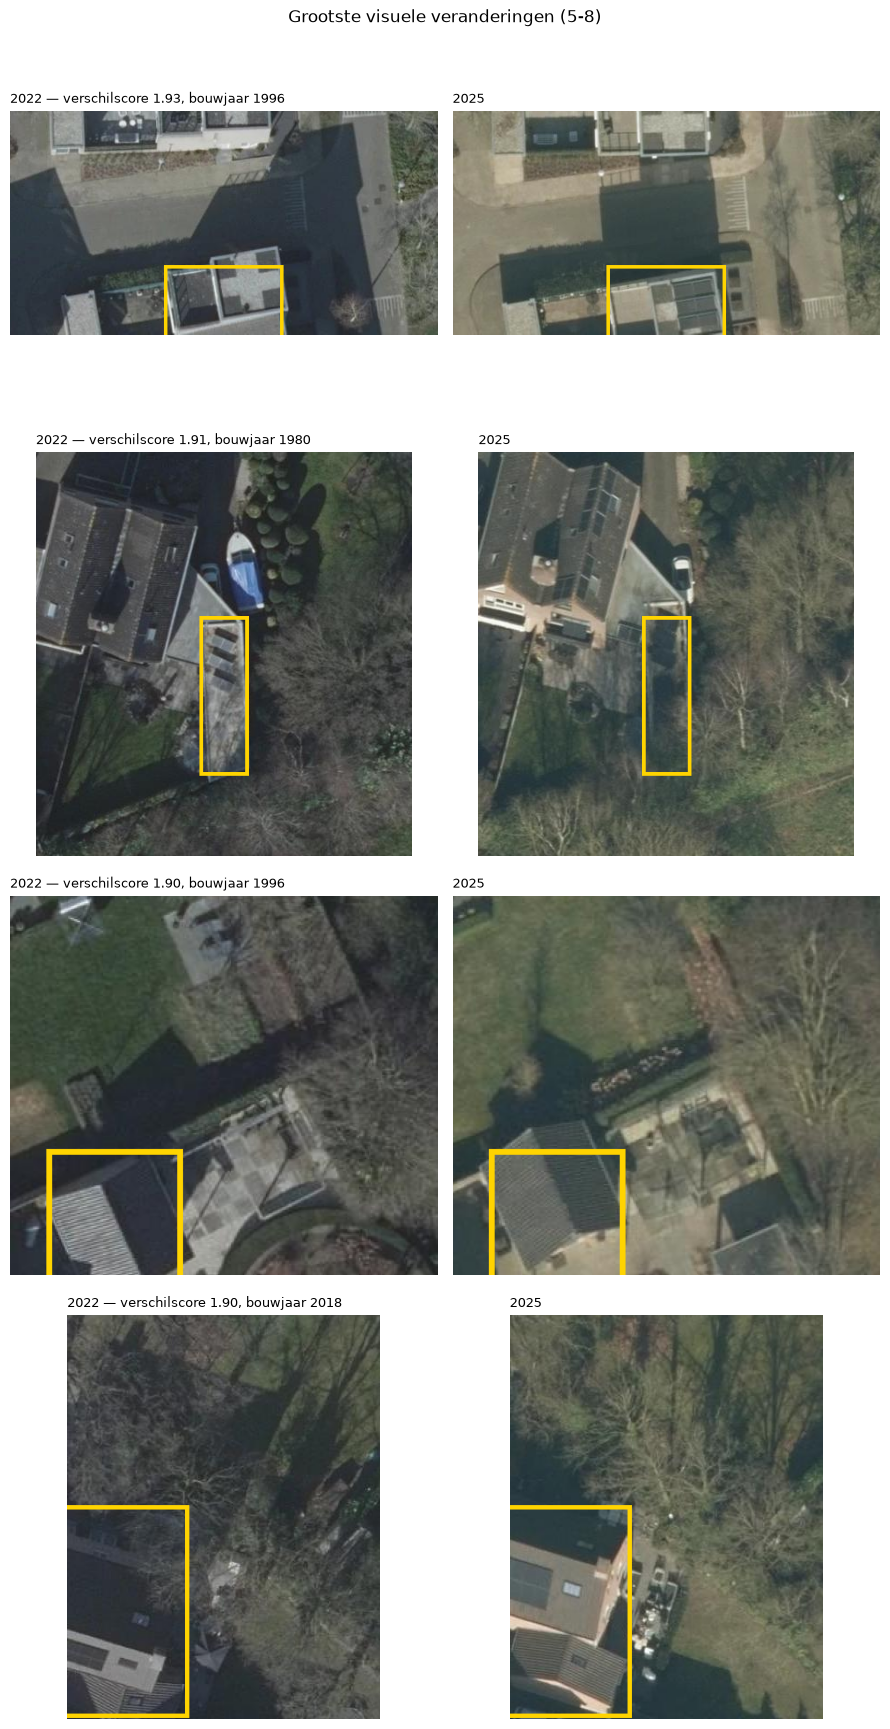

In [7]:
per_tegel = defaultdict(list)
for f in panden:
    geom = shape(f['geometry'])
    if geom.area < 25:
        continue
    per_tegel[tegel_id_voor(geom.centroid.x, geom.centroid.y)].append((f, geom))

scores = []
for tid, groep in per_tegel.items():
    if tid not in idx_oud or tid not in idx_nieuw:
        continue
    a = np.asarray(Image.open(OUD_MAP / idx_oud[tid]['image']).convert('L'), dtype=float)
    b = np.asarray(Image.open(NIEUW_MAP / idx_nieuw[tid]['image']).convert('L'), dtype=float)
    a = (a - a.mean()) / (a.std() + 1e-6)
    b = (b - b.mean()) / (b.std() + 1e-6)
    bbox = idx_oud[tid]['bbox']
    for f, geom in groep:
        gx0, gy0, gx1, gy1 = geom.bounds
        x0 = max(0, int((gx0 - bbox[0]) / RES)); x1 = min(PX, int((gx1 - bbox[0]) / RES))
        y0 = max(0, int((bbox[3] - gy1) / RES)); y1 = min(PX, int((bbox[3] - gy0) / RES))
        if x1 - x0 < 12 or y1 - y0 < 12:
            continue
        scores.append((float(np.abs(b[y0:y1, x0:x1] - a[y0:y1, x0:x1]).mean()), f, geom))

nieuwbouw_ids = {f['properties']['identificatie'] for f in nieuwbouw}
scores.sort(key=lambda s: -s[0])
top = [(s, f, g) for s, f, g in scores
       if f['properties']['identificatie'] not in nieuwbouw_ids][:8]
print(f'{len(scores)} panden gescoord; top 8 (excl. bekende nieuwbouw) hieronder.')
rijen = [(g, f"verschilscore {s:.2f}, bouwjaar {f['properties'].get('bouwjaar')}")
         for s, f, g in top[:4]]
toon_voor_na(rijen, 'Grootste visuele veranderingen (1-4)', bewaar=bewaar_map / 'top_veranderingen.jpg')
rijen = [(g, f"verschilscore {s:.2f}, bouwjaar {f['properties'].get('bouwjaar')}")
         for s, f, g in top[4:]]
toon_voor_na(rijen, 'Grootste visuele veranderingen (5-8)')

## 7. Samenvatting

In [8]:
opp = sum(f['properties'].get('oppervlakte_max') or 0
          for f in nieuwbouw if f['properties']['bouwjaar'] <= 2025)
print(f'Pilotgebied Etten-Leur (1,5 x 1,5 km), 2022 -> 2025:')
print(f'- {sum(1 for f in nieuwbouw if 2022 <= f["properties"]["bouwjaar"] <= 2025)} '
      f'panden nieuw gebouwd (samen ± {opp} m²)')
print(f'- {len(in_aanbouw)} panden in aanbouw op de 2025-foto')
print(f'- {len(sloop)} sloopvergunningen, {len(verbouwing)} geregistreerde verbouwingen')
print(f'- Top visuele veranderingen buiten de BAG om: zie sectie 6 '
      f'(vooral zonnepanelen en dakrenovaties)')

Pilotgebied Etten-Leur (1,5 x 1,5 km), 2022 -> 2025:
- 69 panden nieuw gebouwd (samen ± 2767 m²)
- 26 panden in aanbouw op de 2025-foto
- 5 sloopvergunningen, 4 geregistreerde verbouwingen
- Top visuele veranderingen buiten de BAG om: zie sectie 6 (vooral zonnepanelen en dakrenovaties)


---
**Hoe dit verder groeit**: de verschilscores van sectie 6 zijn precies de kandidaten
die je in Label Studio bevestigt/afwijst, en daarmee trainingsdata voor het echte
verandermodel (zie [docs/mutatiedetectie.md](../docs/mutatiedetectie.md)).

*Bevat gegevens van PDOK: Luchtfoto Beeldmateriaal Nederland (CC-BY 4.0) en de BAG.*